# Qwen3.8-27B on τ³ retail: baseline run

`Qwen/Qwen3.8-27B` used as is, with no fine-tuning, on **τ³ (tau2-bench) retail**: all **114 tasks**, **4 trials** each (456 rollouts), agent temperature **0**, thinking **on**, **GPT-4.1** as the simulated customer, up to 200 steps, 32 rollouts at a time, 1200 s timeout per rollout. It ran on one A100 80GB with vLLM, in bf16.

Data: `results/qwen3.8-27b/q38_run.json` (summary written by `update_json.py` during the run); all 456 conversations are in `results/qwen3.8-27b/tau3_q38_27b_results.json` and can be browsed in `renders/qwen3.8_27b_tau3_retail_4trials.html`.

In [1]:
import json, math, datetime
from pathlib import Path
from collections import Counter
import numpy as np
from IPython.display import HTML, display
# works both in tau-train/qwen3.8-27b/ and in the GitHub repo's notebooks/ folder
P = next(p for p in (Path("results/q38_run.json"), Path("../results/qwen3.8-27b/q38_run.json"), Path("results/qwen3.8-27b/q38_run.json")) if p.exists())
N_TASKS, N_TRIALS, TIMEOUT_S = 114, 4, 1200
C_Q38 = "#7A4E9C"
C_TRIAL = ["#7A4E9C", "#2F5D8A", "#1E7A5C", "#E0883B"]   # trial 1-4
TERM_COL = {"user_stop": "#CFCFCF", "agent_stop": "#9DB8D9", "max_steps": "#E8B04A", "timeout": "#B3261E", "too_many_errors": "#6B6B6B"}
def fmt_min(m):
    if m is None: return "-"
    m = int(round(m)); return f"{m} min" if m < 60 else f"{m // 60} h {m % 60:02d} min"
def table(rows, head=None):
    h = "".join(f"<th style='text-align:left;padding:2px 10px'>{x}</th>" for x in head) if head else ""
    b = "".join("<tr>" + "".join(f"<td style='padding:2px 10px'>{x}</td>" for x in r) + "</tr>" for r in rows)
    return f"<table style='border-collapse:collapse;font-size:13px'>{'<tr>' + h + '</tr>' if h else ''}{b}</table>"
def ok(r): return 1 if (r.get("reward") or 0) >= 1 else 0
def by_task(rows):
    d = {}
    for r in rows: d.setdefault(str(r["task_id"]), {})[int(r["trial"] or 0)] = ok(r)
    return {t: [v[k] for k in sorted(v)] for t, v in d.items()}
def passk(v, k): return math.comb(sum(v), k) / math.comb(len(v), k) if len(v) >= k else None
def mean_se(xs):
    xs = [x for x in xs if x is not None]; n = len(xs)
    if not n: return None, None, 0
    m = sum(xs) / n; return m, (math.sqrt(sum((x - m) ** 2 for x in xs) / (n - 1) / n) if n > 1 else None), n
def load():
    R = json.load(open(P)); rows = R.get("run", {}).get("rows", [])
    return R, rows
R, ROWS = load()
print(f"stage: {R['stage']} | {R['run']['rollouts_done']}/{N_TASKS * N_TRIALS} rollouts | JSON updated {R['updated']}")

stage: finished | 456/456 rollouts | JSON updated 2026-10-05T11:16:44+04:00


## 1. Run info and estimated time

In [2]:
def info_html(R):
    run, pod, cfg, pl = R["run"], R.get("pod", {}), R["config"], R["plan"]
    o = [f"<h4>JSON written {R['updated']} &middot; stage: <span style='color:{C_Q38}'>{R['stage']}</span></h4>"]
    if not R.get("pod_reachable", True): o.append("<p style='color:#B3261E'><b>Pod unreachable</b>, showing the last known state.</p>")
    done, tot = run["rollouts_done"], N_TASKS * N_TRIALS
    p1 = f"{run['pass1']:.1%} &plusmn; {run['pass1_se']:.1%}" if run.get("pass1") is not None and run.get("pass1_se") else "-"
    o.append("<b>Progress</b>" + table([
        ["rollouts done", f"{done} / {tot} ({done / tot:.0%})"], ["passed", run.get("passed", "-")], ["pass^1 so far (&plusmn; s.e.)", p1],
        ["pace", f"{pl['pace_used']:.2f} rollouts / min" if pl.get("pace_used") else "measuring..."],
        ["started", (pl.get("started_at") or "-")[11:16]], ["time left", fmt_min(pl.get("total_min")) if pl.get("remaining") else "done"],
        ["estimated finish (local)", f"<b>{pl.get('done_at') or '-'}</b>"],
        ["GPT-4.1 cost so far / projected", f"${run.get('user_cost', 0):.2f} / ${pl['projected_user_cost']:.2f}" if pl.get("projected_user_cost") else "-"]]))
    o.append("<b>Each trial</b> (estimated finish assumes trials complete in order at the current pace)" + table(
        [[t["trial"], f"{t['done']} / {N_TASKS}", t["passed"], f"{t['pass1']:.1%}" if t["pass1"] is not None else "-",
          "done" if t["done"] >= N_TASKS else fmt_min(t["eta_min"]), t["done_at"] or ("done" if t["done"] >= N_TASKS else "-")] for t in R["trials"]],
        ["trial", "rollouts", "passed", "pass^1", "time left", "finish at (local)"]))
    o.append("<b>Settings</b>" + table([[k.replace("_", " "), v] for k, v in cfg.items()]))
    o.append("<b>Machine</b>" + table([["address", pod.get("host")], ["GPU (name, load, memory used, total)", pod.get("gpu") or "-"],
        ["disk / RAM disk", f"{pod.get('disk') or '-'} &middot; {pod.get('shm') or '-'}"], ["vLLM answering", "yes" if pod.get("vllm_up") else "no"],
        ["processes alive", ", ".join(k for k, v in (pod.get("procs") or {}).items() if v) or "none"],
        ["last tau2 log line", (pod.get("tau2_log_tail") or "-").replace("<", "&lt;")[-150:]]]))
    o.append("<b>Recent events</b>" + table([[e["time"][11:19], e["event"].replace("<", "&lt;")] for e in R.get("events", [])[-8:]]))
    return "".join(o)
display(HTML(info_html(R)))

---
# Graphs

In [3]:
import matplotlib.pyplot as plt, matplotlib.ticker as mtick
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#B8B8B8", "axes.grid": True, "grid.color": "#E6E6E6",
                     "grid.linewidth": 0.8, "axes.axisbelow": True, "lines.linewidth": 2, "legend.frameon": False, "xtick.color": "#555", "ytick.color": "#555"})
PCT = mtick.PercentFormatter(1)
def placeholder(title, text="no data yet"):
    fig, ax = plt.subplots(figsize=(10, 2.2)); ax.set_title(title); ax.axis("off")
    ax.text(0.5, 0.5, text, ha="center", va="center", fontsize=14, color="#888", transform=ax.transAxes); plt.show()
def bar_labels(ax, bars, fmt="{:.0%}", errs=None):   # value above each bar (above the error cap if there is one)
    for b, e in zip(bars, errs if errs is not None else [0] * len(bars)):
        ax.annotate(fmt.format(b.get_height()), (b.get_x() + b.get_width() / 2, b.get_y() + b.get_height() + (e or 0)), xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9, color="#333")
    if ax.get_autoscaley_on(): ax.margins(y=0.12)
def legend_below(fig, ncol=4):
    h, l = [], []
    for ax in fig.axes:
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if ll not in l and not ll.startswith("_"): h.append(hh); l.append(ll)
    if h: fig.legend(h, l, loc="lower center", ncol=ncol, bbox_to_anchor=(0.5, -0.02)); fig.tight_layout(rect=(0, 0.08, 1, 1))
    else: fig.tight_layout()

In [4]:
R, ROWS = load()
BY = by_task(ROWS)
def parse(s):
    try: return datetime.datetime.fromisoformat(s)
    except Exception: return None
FIN = sorted(t.astimezone().replace(tzinfo=None) for t in (parse(x) for x in R["run"].get("finish_times", [])) if t)   # local wall-clock time
TR = {}
for r in ROWS: TR.setdefault(int(r["trial"] or 0), []).append(ok(r))
def passk_curve(by, kmax):
    return {k: mean_se(passk(v, k) for v in by.values()) for k in range(1, kmax + 1)}
PK = passk_curve(BY, N_TRIALS)
BARS = {"all trials": (mean_se(ok(r) for r in ROWS), "#555555")}   # pass^1 overall and per trial
for k, v in sorted(TR.items()): BARS[f"trial {k + 1}"] = (mean_se(v), C_TRIAL[k % 4])
print(f"{len(ROWS)} rollouts so far | tasks with all {N_TRIALS} trials: {sum(len(v) == N_TRIALS for v in BY.values())}")

456 rollouts so far | tasks with all 4 trials: 114


## 2. Pass rates: overall, each trial, and pass^k

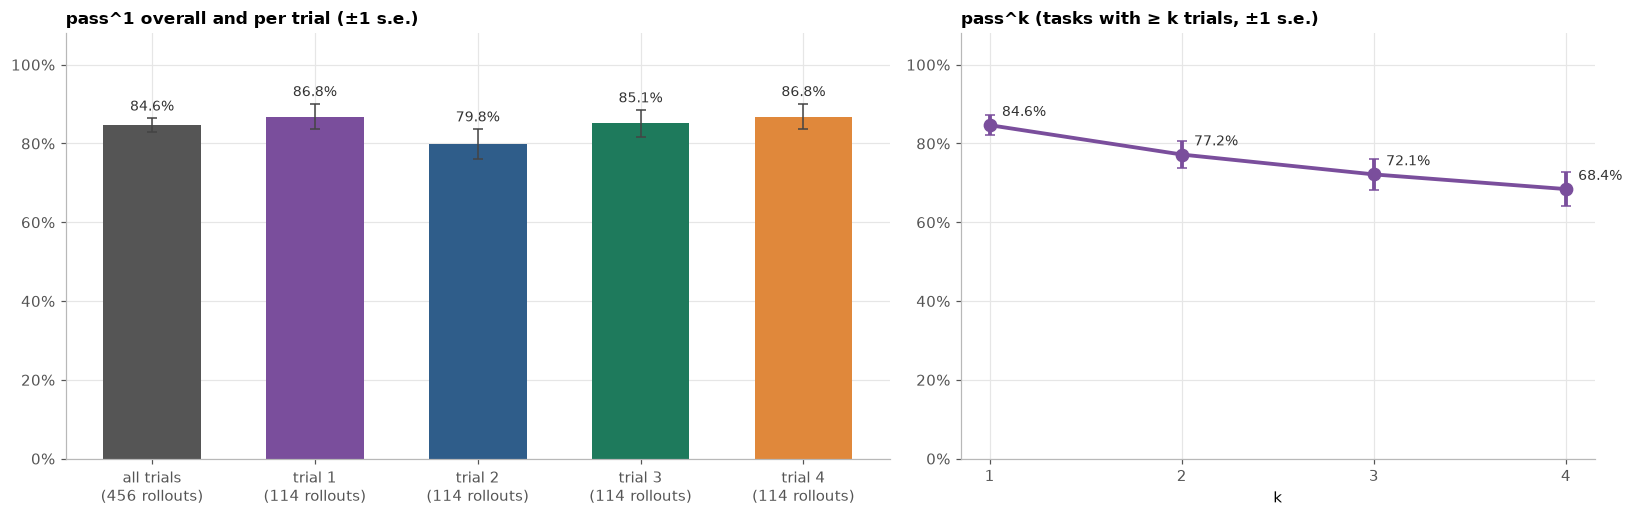

pass^k: {'pass^1': '84.6% over 114 tasks', 'pass^2': '77.2% over 114 tasks', 'pass^3': '72.1% over 114 tasks', 'pass^4': '68.4% over 114 tasks'}


In [5]:
if ROWS:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw=dict(width_ratios=[1.3, 1]))
    names = list(BARS); vals = [BARS[n][0][0] for n in names]; errs = [BARS[n][0][1] or 0 for n in names]
    b = a1.bar([f"{n}\n({BARS[n][0][2]} rollouts)" for n in names], vals, yerr=errs, color=[BARS[n][1] for n in names], width=0.6, error_kw=dict(ecolor="#444", elinewidth=1, capsize=3)); bar_labels(a1, b, "{:.1%}", errs)
    a1.set_title("pass^1 overall and per trial (±1 s.e.)")
    ks = [k for k in PK if PK[k][0] is not None]
    a2.errorbar(ks, [PK[k][0] for k in ks], yerr=[PK[k][1] or 0 for k in ks], color=C_Q38, lw=2.5, marker="o", ms=8, capsize=3)
    for k in ks: a2.annotate(f"{PK[k][0]:.1%}", (k, PK[k][0]), xytext=(8, 6), textcoords="offset points", fontsize=9, color="#333")
    a2.set_title("pass^k (tasks with ≥ k trials, ±1 s.e.)"); a2.set_xlabel("k"); a2.set_xticks(range(1, N_TRIALS + 1))
    for a in (a1, a2): a.set_ylim(0, 1.08); a.yaxis.set_major_formatter(PCT)
    fig.tight_layout(); plt.show()
    print("pass^k:", {f"pass^{k}": f"{PK[k][0]:.1%} over {PK[k][2]} tasks" for k in ks})
else:
    placeholder("pass rates", "no rollout finished yet")

## 3. All 4 trials: pass^1 to pass^4, and how many trials each task passed
pass^k is the chance that all k attempts at a task succeed (estimated over the 4 trials of each task).

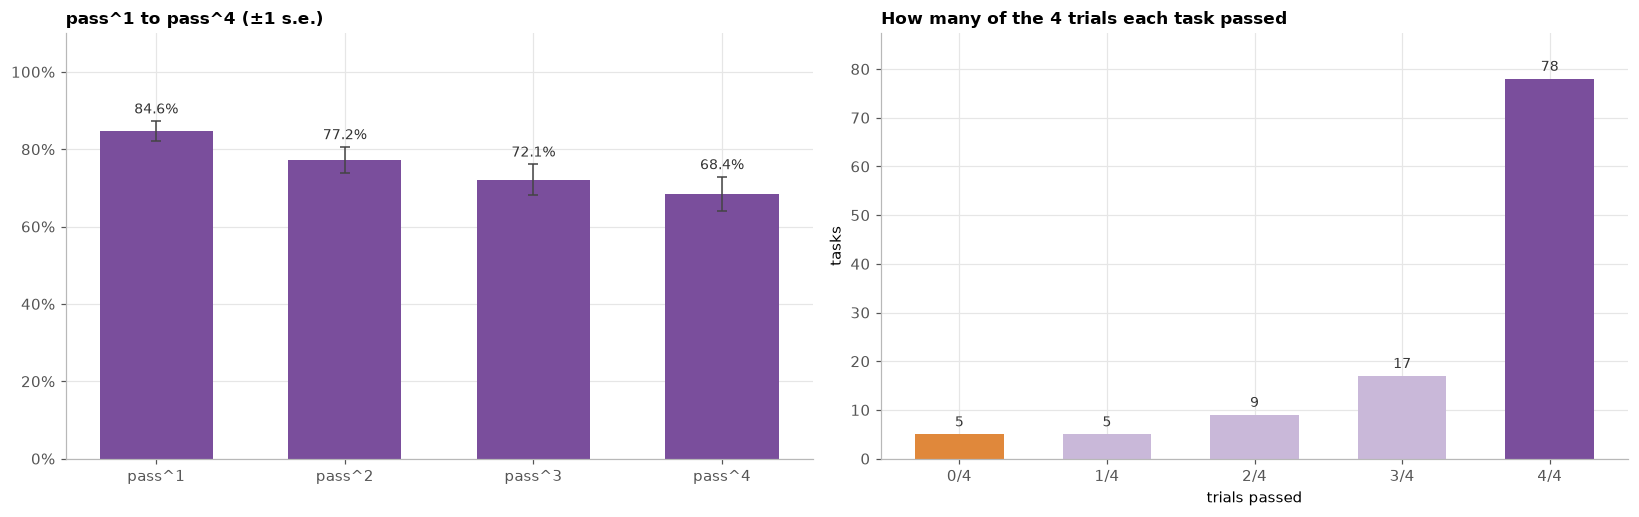

pass^1: 84.6% (114 tasks) | pass^2: 77.2% (114 tasks) | pass^3: 72.1% (114 tasks) | pass^4: 68.4% (114 tasks) | tasks with all 4 trials: 114


In [6]:
if ROWS:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.8))
    ks = [k for k in range(1, N_TRIALS + 1) if PK[k][0] is not None]; errs = [PK[k][1] or 0 for k in ks]
    b = a1.bar([f"pass^{k}" for k in ks], [PK[k][0] for k in ks], yerr=errs, color=C_Q38, width=0.6, error_kw=dict(ecolor="#444", elinewidth=1, capsize=3)); bar_labels(a1, b, "{:.1%}", errs)
    a1.set_ylim(0, 1.1); a1.yaxis.set_major_formatter(PCT); a1.set_title(f"pass^1 to pass^{N_TRIALS} (±1 s.e.)")
    full = [v for v in BY.values() if len(v) == N_TRIALS]; cnt = Counter(sum(v) for v in full)
    b = a2.bar([f"{i}/{N_TRIALS}" for i in range(N_TRIALS + 1)], [cnt[i] for i in range(N_TRIALS + 1)], width=0.6, color=["#E0883B"] + ["#C9B8D9"] * (N_TRIALS - 1) + [C_Q38]); bar_labels(a2, b, "{:.0f}")
    a2.set_title(f"How many of the {N_TRIALS} trials each task passed"); a2.set_xlabel("trials passed"); a2.set_ylabel("tasks")
    fig.tight_layout(); plt.show()
    print(" | ".join(f"pass^{k}: {PK[k][0]:.1%} ({PK[k][2]} tasks)" for k in ks) + f" | tasks with all {N_TRIALS} trials: {len(full)}")
else:
    placeholder("pass^1 to pass^4", "no rollout finished yet")

## 4. Running pass rate

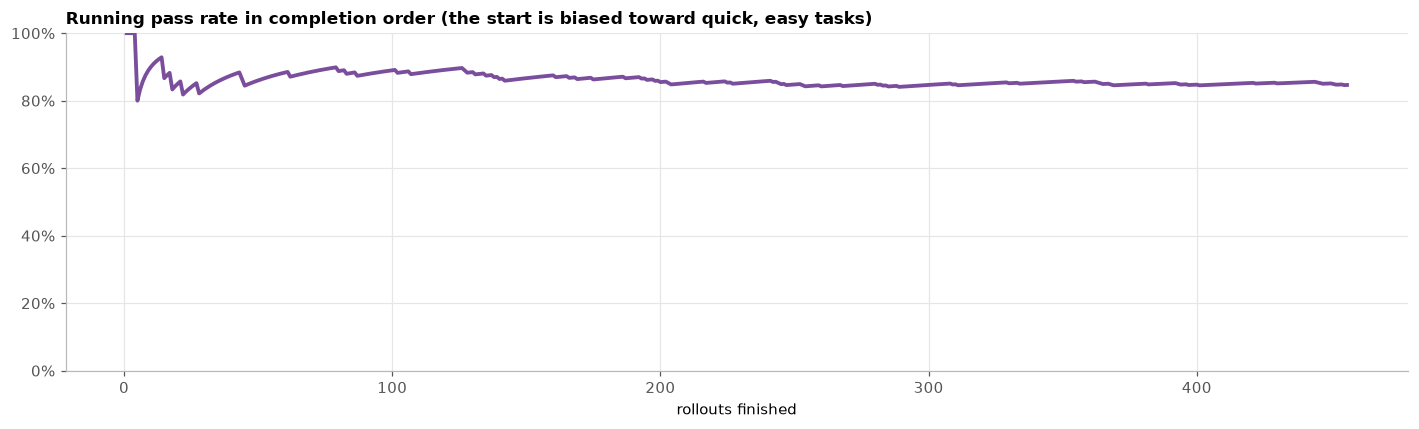

In [7]:
if ROWS:
    rp = R["run"]["running_pass1"]; fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(range(1, len(rp) + 1), rp, color=C_Q38, lw=2.5, label="_running pass rate")
    ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(PCT); ax.set_xlabel("rollouts finished")
    ax.set_title("Running pass rate in completion order (the start is biased toward quick, easy tasks)"); fig.tight_layout(); plt.show()
else:
    placeholder("Running pass rate", "no rollout finished yet")

## 5. Every task and trial

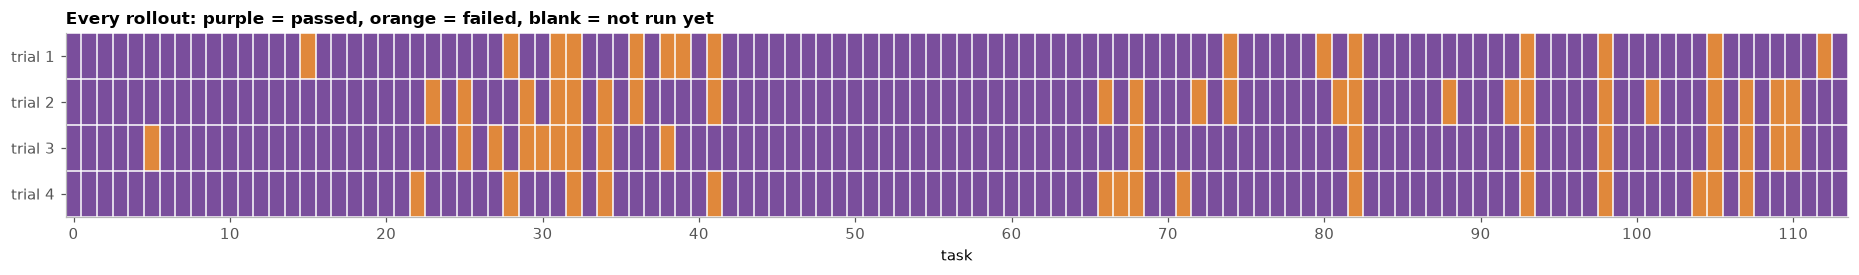

tasks with all 4 trials: 114 | always pass 78 | always fail 5 | mixed 31


In [8]:
if ROWS:
    from matplotlib.colors import ListedColormap
    tasks = sorted({str(i) for i in range(N_TASKS)} | set(BY), key=lambda x: int(x) if x.isdigit() else x)
    cell = {(str(r["task_id"]), int(r["trial"] or 0)): ok(r) for r in ROWS}
    z = np.array([[cell.get((t, k), np.nan) for t in tasks] for k in range(N_TRIALS)], float)
    fig, ax = plt.subplots(figsize=(17, 2.6))
    ax.imshow(np.ma.masked_invalid(z), aspect="auto", cmap=ListedColormap(["#E0883B", C_Q38]), vmin=0, vmax=1, interpolation="nearest")
    ax.set_yticks(range(N_TRIALS), [f"trial {k + 1}" for k in range(N_TRIALS)]); ax.set_xticks(range(0, len(tasks), 10), [tasks[i] for i in range(0, len(tasks), 10)])
    ax.set_xticks(np.arange(-.5, len(tasks)), minor=True); ax.set_yticks(np.arange(-.5, N_TRIALS), minor=True)
    ax.grid(which="minor", color="white", lw=1); ax.grid(which="major", visible=False); ax.tick_params(which="minor", length=0); ax.set_xlabel("task")
    ax.set_title("Every rollout: purple = passed, orange = failed, blank = not run yet"); fig.tight_layout(); plt.show()
    cons = Counter(("all pass" if all(v) else "all fail" if not any(v) else "mixed") for v in BY.values() if len(v) == N_TRIALS)
    print(f"tasks with all {N_TRIALS} trials: {sum(cons.values())} | always pass {cons['all pass']} | always fail {cons['all fail']} | mixed {cons['mixed']}")
else:
    placeholder("Per-task results", "no rollout finished yet")

## 6. How rollouts ended, how long they took, and how chatty they were

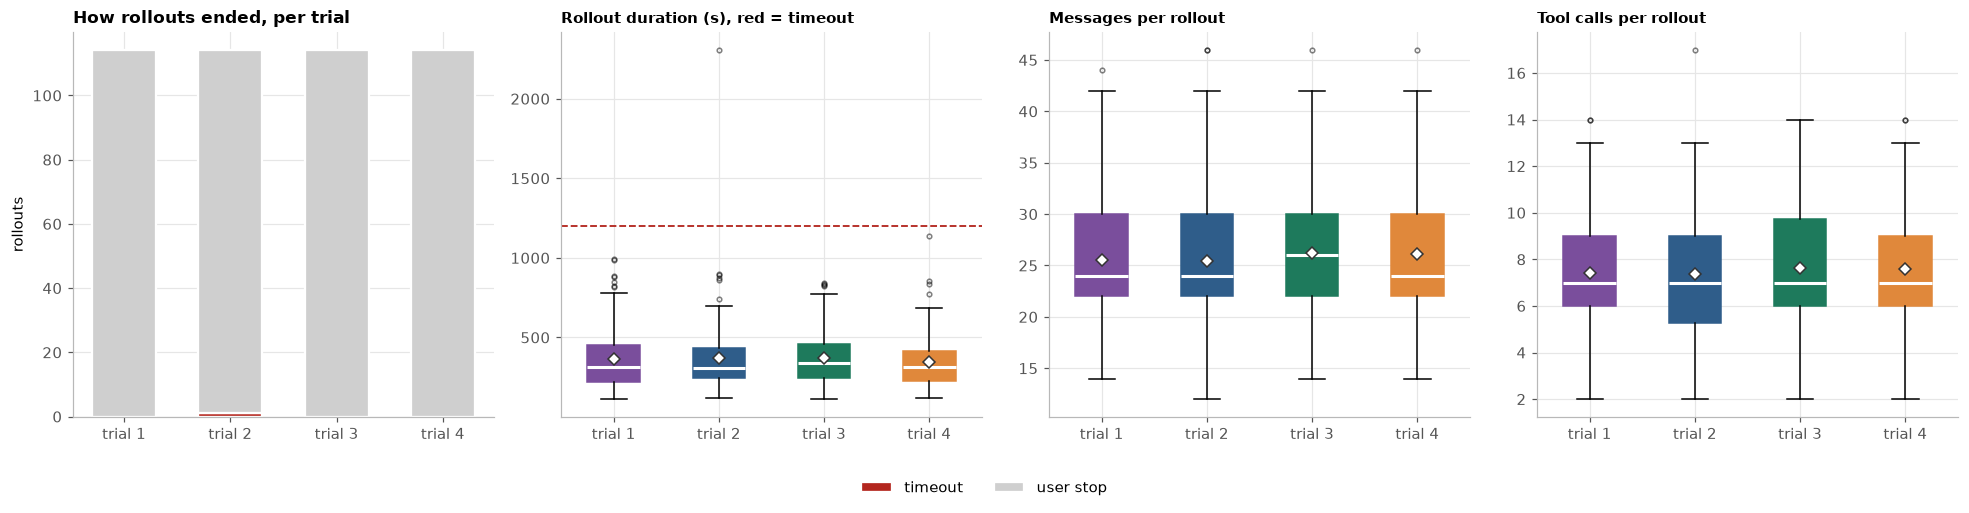

In [9]:
if ROWS:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
    terms = sorted({str(r["term"]) for r in ROWS}); trials = sorted(TR); bottom = np.zeros(len(trials))
    for t in terms:
        v = np.array([sum(1 for r in ROWS if int(r["trial"] or 0) == k and str(r["term"]) == t) for k in trials], float)
        axes[0].bar([f"trial {k + 1}" for k in trials], v, bottom=bottom, color=TERM_COL.get(t, "#888"), width=0.6, edgecolor="white", linewidth=1.5, label=t.replace("_", " ")); bottom += v
    axes[0].set_title("How rollouts ended, per trial"); axes[0].set_ylabel("rollouts")
    for ax, key, title in zip(axes[1:], ("duration", "n_messages", "n_tool_calls"), ("Rollout duration (s), red = timeout", "Messages per rollout", "Tool calls per rollout")):
        bp = ax.boxplot([[r.get(key) for r in ROWS if int(r["trial"] or 0) == k and r.get(key) is not None] for k in trials], tick_labels=[f"trial {k + 1}" for k in trials], widths=0.5, patch_artist=True, showmeans=True,
                        meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333", markersize=6), medianprops=dict(color="white", lw=2), flierprops=dict(marker="o", ms=3, alpha=.5))
        for patch, k in zip(bp["boxes"], trials): patch.set_facecolor(C_TRIAL[k % 4]); patch.set_edgecolor(C_TRIAL[k % 4])
        ax.set_title(title, fontsize=10)
    axes[1].axhline(TIMEOUT_S, color="#B3261E", ls="--", lw=1.2)
    legend_below(fig, 5); plt.show()
else:
    placeholder("Durations", "no rollout finished yet")